
# 📘 Day 17: Logistic Regression (Theory + Hands-On)

## Covered Topics:
- Classification Concepts
- Sigmoid Function
- Binary Logistic Regression
- Multinomial Logistic Regression
- Ordinal Logistic Regression
- Multi-Label Classification

---

## 🎯 Objective
Build strong intuition + hands-on understanding of **all types of logistic regression**


Logistic Regression (Core Concept)

Despite the name…

👉 It is a classification algorithm, not regression.

Instead of predicting numbers…

👉 Predict probability between 0 and 1

Notice:

S-shaped curve
Smooth transition from 0 → 1
Decision boundary at 0.5

Core Idea

Classification = predicting categories (labels)

Regression → predicts numbers (price = 100)
Classification → predicts classes (spam / not spam)

Problem	Type
Fraud detection -	Fraud / Not Fraud
Loan approval-	Approve / Reject
Disease detection-	Positive / Negative
Customer churn-	Stay / Leave


Binary Classification

2 classes only

Yes / No
0 / 1
Fraud / Not Fraud

👉 Most common in real-world ML

🔹 Multi-Class Classification

More than 2 classes

Email → {Primary, Social, Promotions}
Digit recognition → {0–9}
🔹 Multi-Label Classification

One item → multiple labels

Movie → {Action, Comedy}
News → {Politics, Economy}

Ordinal Logistic Regression

👉 Output: Ordered categories

Example:

Credit Rating: Low < Medium < High


# 🧠 Logistic Regression Theory

## Why not Linear Regression?
- Output can be <0 or >1 ❌
- Not valid probability

## Sigmoid Function

$$
p = \frac{1}{1 + e^{-z}}
$$

- Converts any value → (0,1)
- Used to predict probability

## Decision Boundary
- p > 0.5 → Class 1
- p < 0.5 → Class 0

---

## Types of Logistic Regression

| Type | Description |
|------|------------|
| Binary | 2 classes |
| Multinomial | Multiple classes |
| Ordinal | Ordered classes |
| Multi-label | Multiple labels per sample |


## 🔹 1. Binary Logistic Regression

Accuracy: 1.0


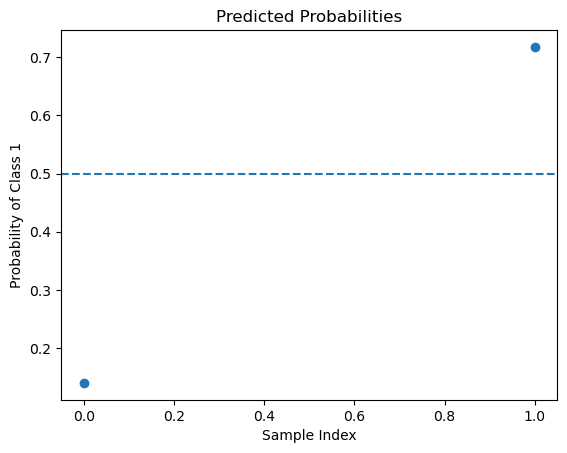

In [4]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Dataset
df = pd.DataFrame({
    "age": [25, 45, 35, 50, 23, 40],
    "salary": [20000, 50000, 30000, 60000, 22000, 52000],
    "churn": [0, 1, 0, 1, 0, 1]
})

X = df[["age", "salary"]]
y = df["churn"]

# 🔹 Step 1: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Step 2: Scaling (FIT ONLY ON TRAIN DATA)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Step 3: Model Training
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 🔹 Step 4: Prediction
pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

probs = model.predict_proba(X_test_scaled)[:, 1]

plt.scatter(range(len(probs)), probs)
plt.axhline(y=0.5, linestyle='--')

plt.title("Predicted Probabilities")
plt.xlabel("Sample Index")
plt.ylabel("Probability of Class 1")

plt.show()


## 🔹 2. Multinomial Logistic Regression

In [9]:

# 📌 Goal:
# We are building a model to classify iris flowers into 3 categories
# based on their physical measurements.

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 🔹 Step 1: Load Dataset
data = load_iris()

X = data.data   # Features: sepal length, sepal width, petal length, petal width
y = data.target # Target (labels)

# 📌 Target Values Meaning:
# 0 → Setosa
# 1 → Versicolor
# 2 → Virginica
# 👉 This is a MULTI-CLASS classification problem (3 classes)

# 🔹 Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Step 3: Create Pipeline
# Why Pipeline?
# - Ensures scaling + model training happen in correct order
# - Avoids data leakage
# - Industry best practice

pipeline = Pipeline([
    ("scaler", StandardScaler()),   # 🔹 Feature scaling
    ("model", LogisticRegression(
        multi_class='multinomial',  # 🔹 Handles multiple classes directly
        max_iter=200                # 🔹 Increase iterations for convergence
    ))
])

# 🔹 Step 4: Train Model
pipeline.fit(X_train, y_train)

# 🔹 Step 5: Predictions
pred = pipeline.predict(X_test)

# 🔹 Step 6: Evaluation
print("Accuracy:", accuracy_score(y_test, pred))

# 🔹 Step 7: (Optional) Probability Output
# Shows confidence for each class
probs = pipeline.predict_proba(X_test)
print("\nSample Probabilities:\n", probs[:3])

Accuracy: 1.0

Sample Probabilities:
 [[1.14571961e-02 8.75978526e-01 1.12564278e-01]
 [9.64411302e-01 3.55882864e-02 4.11287569e-07]
 [3.77322994e-08 2.88231142e-03 9.97117651e-01]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 🔹 3. Ordinal Logistic Regression

🧠 What is One-vs-Rest (OvR)?

👉 OvR = Convert a multi-class problem into multiple binary problems

Instead of solving:

“Which class out of 3?”

We solve:

“Is it Class 0 or NOT?”
“Is it Class 1 or NOT?”
“Is it Class 2 or NOT?”

🎯 Core Idea

If you have K classes, OvR creates:

👉 K separate binary classifiers

📦 Example (3 Classes: A, B, C)

Original problem:

A vs B vs C

OvR converts into:

Model	Task
Model 1	A vs (B, C)
Model 2	B vs (A, C)
Model 3	C vs (A, B)

In [14]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 📌 Goal:
# Predict rating (Low / Medium / High) based on income

# 🔹 Step 1: Create Larger Dataset
np.random.seed(42)

n = 100

income = np.random.randint(20, 120, n)

# Create ordinal target based on income
rating = []
for inc in income:
    if inc < 40:
        rating.append(0)   # Low
    elif inc < 80:
        rating.append(1)   # Medium
    else:
        rating.append(2)   # High

df = pd.DataFrame({
    "income": income,
    "rating": rating
})

# 🔹 Step 2: Features & Target
X = df[["income"]]
y = df["rating"]

# 🔹 Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Step 4: Pipeline (Scaling + Model)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        multi_class='ovr', 
        max_iter=200
    ))
])

# 🔹 Step 5: Train Model
pipeline.fit(X_train, y_train)

# 🔹 Step 6: Predict
pred = pipeline.predict(X_test)

# 🔹 Step 7: Evaluate
print("Accuracy:", accuracy_score(y_test, pred))

# 🔹 Step 8: Sample Predictions
sample = pd.DataFrame({"income": [25, 55, 95]})
print("\nSample Predictions:", pipeline.predict(sample))


Accuracy: 0.8

Sample Predictions: [0 1 2]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


## 🔹 4. Multi-Label Classification

In [17]:
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 📌 Goal:
# Predict multiple genres (Action, Romance) for a movie

np.random.seed(42)

# 🔹 Step 1: Create More Realistic Dataset (~20 samples)
n = 20

action_score = np.random.randint(1, 10, n)
duration = np.random.randint(80, 180, n)

# Create labels with some logic + noise
Action = (action_score > 5).astype(int)
Romance = (action_score < 6).astype(int)

# Add slight randomness (real-world noise)
noise = np.random.choice([0,1], size=n, p=[0.8,0.2])
Romance = np.abs(Romance - noise)

X = pd.DataFrame({
    "action_score": action_score,
    "duration": duration
})

y = pd.DataFrame({
    "Action": Action,
    "Romance": Romance
})

# 🔹 Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Step 3: Pipeline (Scaling + Multi-label Model)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputClassifier(
        LogisticRegression(max_iter=200)
    ))
])

# 🔹 Step 4: Train Model
pipeline.fit(X_train, y_train)

# 🔹 Step 5: Predict
pred = pipeline.predict(X_test)

# 🔹 Step 6: Evaluate
print("Predictions:\n", pred)
print("\nActual:\n", y_test.values)

# ⚠️ Note: Accuracy in multi-label is strict (all labels must match)
print("\nAccuracy:", accuracy_score(y_test, pred))

# 🔹 Step 7: Try New Data
new_movies = pd.DataFrame({
    "action_score": [2, 6, 9],
    "duration": [95, 140, 175]
})

print("\nNew Predictions:\n", pipeline.predict(new_movies))

from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

Predictions:
 [[1 0]
 [0 1]
 [0 1]
 [0 1]]

Actual:
 [[1 0]
 [1 0]
 [0 1]
 [0 0]]

Accuracy: 0.5

New Predictions:
 [[0 1]
 [1 0]
 [1 0]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.33      1.00      0.50         1

   micro avg       0.50      0.67      0.57         3
   macro avg       0.67      0.75      0.58         3
weighted avg       0.78      0.67      0.61         3
 samples avg       0.50      0.50      0.50         3



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
